![NVIDIA Logo](images/nvidia.png)

# Exercise: Parameterized PCAP Analysis

For this exercise you will be working with a collection of network packet capture (PCAP) data containing the following columns.

- Timestamp (`timestamp`): The time the packet was captured in microseconds.
- Host IP (`host_ip`): The IP address of the host capturing the packet.
- Data length (`data_len`): The size of the packet in bytes.
- Data (`data`): The actual payload of the packet (empty for some packets, contains request data for others).
- MAC Addresses (`src_mac`, `dest_mac`): The source and destination MAC addresses.
- Protocol (`protocol`): The transport layer protocol (e.g., 6 for TCP).
- Source & Destination IPs (`src_ip`, `dest_ip`): The IP addresses of the sender and receiver.
- Source & Destination Ports (`src_port`, `dest_port`): The associated port numbers for the communication.
- Flags (`flags`): TCP flag values indicating the state of the connection.

In [1]:
import cudf

In [2]:
input_file = 'data/pcap_dump.jsonlines'

In [3]:
pcap = cudf.read_json(input_file, lines=True)

In [4]:
len(pcap)

537241

In [5]:
pcap.head()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
0,1617810893485061,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28782,6443,16
1,1617810893525610,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,28782,16
2,1617810893640893,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,17
3,1617810893682471,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,69.192.193.45,10.100.8.98,80,49192,17
4,1617810893682486,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,16


---

## Network Traffic Analysis Function

The following function can be used for a variety of network traffic analysis tasks on the PCAP data.

In [6]:
def filter_and_aggregate_network_traffic(
    df: cudf.DataFrame,
    filter_ip: str = None,
    filter_port: str = None,
    filter_protocol: str = None
) -> cudf.DataFrame:
    """
    Filters and aggregates network traffic data based on optional parameters.
    
    Args:
        df (cudf.DataFrame): The input network traffic log.
        filter_ip (str, optional): IP address to filter packets (either src_ip or dest_ip).
        filter_port (str, optional): Port to filter packets (either src_port or dest_port).
        filter_protocol (str, optional): Protocol number to filter packets (e.g., "6" for TCP).

    Returns:
        cudf.DataFrame: Aggregated data with packet counts and total data transferred.
    """

    # Convert data_len to numeric (since it appears as a string in sample data)
    df["data_len"] = df["data_len"].astype("int32")

    # Apply filtering conditions
    if filter_ip:
        df = df[(df["src_ip"] == filter_ip) | (df["dest_ip"] == filter_ip)]
    
    if filter_port:
        df = df[(df["src_port"] == filter_port) | (df["dest_port"] == filter_port)]
    
    if filter_protocol:
        df = df[df["protocol"] == filter_protocol]

    # Aggregate data
    result = (
        df.groupby(["src_ip", "dest_ip", "protocol"])
        .agg({"data_len": "sum", "timestamp": "count"})
        .reset_index()
        .rename(columns={"data_len": "total_bytes", "timestamp": "packet_count"})
    )

    return result


Below are several examples of how `filter_and_aggregate_network_traffic` can be utilized.

### General Traffic Analysis

**Aggregate all traffic without filtering (i.e., analyze all packets)**

Get an overview of all network traffic, grouped by (`src_ip`, `dest_ip`, `protocol`), including total bytes transferred and packet count.

In [7]:
result_all_traffic = filter_and_aggregate_network_traffic(pcap)

In [8]:
result_all_traffic

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,10.100.8.98,128.220.159.226,6,551,6
1,10.100.8.98,156.40.212.153,6,702,6
2,10.100.8.98,128.220.192.230,6,2496,26
3,10.100.8.98,104.18.15.213,6,555,6
4,69.192.193.45,10.100.8.98,6,4982,44
5,10.100.8.98,151.101.54.137,6,483,6
6,10.100.8.98,74.208.253.126,6,527,6
7,10.100.8.98,10.100.1.237,6,5342958,98861
8,151.101.54.137,10.100.8.98,6,854,5
9,10.100.1.237,10.100.8.98,6,3217170,59577


### Analyzing Traffic for a Specific IP

**Check traffic involving `10.100.8.98`**

Investigate communication patterns for a specific host, such as identifying high-traffic sources or destinations.

In [9]:
result_ip_specific = filter_and_aggregate_network_traffic(pcap, filter_ip="10.100.8.98")

In [10]:
result_ip_specific

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,10.100.8.98,128.220.159.226,6,551,6
1,10.100.8.98,156.40.212.153,6,702,6
2,10.100.8.98,128.220.192.230,6,2496,26
3,10.100.8.98,104.18.15.213,6,555,6
4,69.192.193.45,10.100.8.98,6,4982,44
5,10.100.8.98,151.101.54.137,6,483,6
6,10.100.8.98,74.208.253.126,6,527,6
7,10.100.8.98,10.100.1.237,6,5342958,98861
8,151.101.54.137,10.100.8.98,6,854,5
9,10.100.1.237,10.100.8.98,6,3217170,59577


### Analyzing Traffic for a Specific Port

**Find traffic related to HTTP (port 80)**

Identify all HTTP-related network activity, which could reveal external web requests or metadata queries.

In [11]:
result_http_traffic = filter_and_aggregate_network_traffic(pcap, filter_port="80")

In [12]:
result_http_traffic

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,169.254.169.254,10.100.8.98,6,17983307,147449
1,104.18.15.213,10.100.8.98,6,616,4
2,69.192.193.45,10.100.8.98,6,4982,44
3,10.100.8.98,128.220.159.226,6,551,6
4,10.100.8.98,128.220.192.230,6,2496,26
5,151.101.54.167,10.100.8.98,6,850,5
6,156.40.212.153,10.100.8.98,6,356,4
7,128.220.192.230,10.100.8.98,6,2937,17
8,10.100.8.98,156.40.212.153,6,702,6
9,74.208.253.126,10.100.8.98,6,578,4


### Filtering by Protocol

**Find all TCP (protocol 6) traffic**

Get insights into TCP traffic, which is common for most web and API communications.

In [13]:
result_tcp_traffic = filter_and_aggregate_network_traffic(pcap, filter_protocol="6")

In [14]:
result_tcp_traffic

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,10.100.8.98,128.220.159.226,6,551,6
1,10.100.8.98,156.40.212.153,6,702,6
2,10.100.8.98,128.220.192.230,6,2496,26
3,10.100.8.98,104.18.15.213,6,555,6
4,69.192.193.45,10.100.8.98,6,4982,44
5,10.100.8.98,151.101.54.137,6,483,6
6,10.100.8.98,74.208.253.126,6,527,6
7,10.100.8.98,10.100.1.237,6,5342958,98861
8,151.101.54.137,10.100.8.98,6,854,5
9,10.100.1.237,10.100.8.98,6,3217170,59577


### Combining Multiple Filters

**Find TCP traffic (protocol=6) related to `10.100.8.98`**

Identify all TCP-based connections involving a specific host.

In [15]:
result_tcp_for_ip = filter_and_aggregate_network_traffic(pcap, filter_ip="10.100.8.98", filter_protocol="6")

In [16]:
result_tcp_for_ip

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,10.100.8.98,128.220.159.226,6,551,6
1,10.100.8.98,156.40.212.153,6,702,6
2,10.100.8.98,128.220.192.230,6,2496,26
3,10.100.8.98,104.18.15.213,6,555,6
4,69.192.193.45,10.100.8.98,6,4982,44
5,10.100.8.98,151.101.54.137,6,483,6
6,10.100.8.98,74.208.253.126,6,527,6
7,10.100.8.98,10.100.1.237,6,5342958,98861
8,151.101.54.137,10.100.8.98,6,854,5
9,10.100.1.237,10.100.8.98,6,3217170,59577


**Find HTTP (port 80) traffic for 10.100.8.98**

Detect outgoing HTTP requests from the machine (e.g., metadata queries, external API requests).

In [17]:
result_http_for_ip = filter_and_aggregate_network_traffic(pcap, filter_ip="10.100.8.98", filter_port="80")

In [18]:
result_http_for_ip

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,169.254.169.254,10.100.8.98,6,17983307,147449
1,104.18.15.213,10.100.8.98,6,616,4
2,69.192.193.45,10.100.8.98,6,4982,44
3,10.100.8.98,128.220.159.226,6,551,6
4,10.100.8.98,128.220.192.230,6,2496,26
5,151.101.54.167,10.100.8.98,6,850,5
6,156.40.212.153,10.100.8.98,6,356,4
7,128.220.192.230,10.100.8.98,6,2937,17
8,10.100.8.98,156.40.212.153,6,702,6
9,74.208.253.126,10.100.8.98,6,578,4


### Investigating Potential AWS Metadata Service Access

**Find AWS Metadata Service queries**

Identify whether any instances are making metadata service requests, which could indicate application behavior or security risks.

In [19]:
result_aws_metadata = filter_and_aggregate_network_traffic(pcap, filter_ip="169.254.169.254", filter_port="80")

In [20]:
result_aws_metadata

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,169.254.169.254,10.100.8.98,6,17983307,147449
1,10.100.8.98,169.254.169.254,6,13113323,147582


---

## Exercise Objective

Create a Morpheus pipeline that reads our PCAP data and sends it through a custom stage of your creation which utilizes the `filter_and_aggregate_network_traffic` function defined above.

The custom stage should be parameterized such that we can reuse it in different contexts depending on what we would like to accomplish.

Feel free to test your pipeline using any (or all) of the examples above, or by filtering and aggregating on other values you find interesting.

---

## Imports

You will likely need to use the following imports in your work.

In [39]:
# %env PYTHONIOENCODING=utf-8
import typing
import logging

from IPython.display import Image
import cudf

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.messages import MessageMeta

from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.cli.register_stage import register_stage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
from mrc.core import operators as ops

---

## Your Work Here

Build and run your pipeline in the space provided below. By all means feel free to create additional code cells for your work, which you can do by clicking the `+` button in the Jupyter menu bar at the top of this notebook.

If you get stuck, a solution is provided below, which you view by expanding the *Solution* section below.

In [40]:
@register_stage("filter-and-aggregate")
class FilterAndAggregate(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 filter_ip: str = None,
                 filter_port: str = None,
                 filter_protocol: str = None
                ):
        super().__init__(config)
        
        self._filter_ip = filter_ip
        self._filter_port = filter_port
        self._filter_protocol = filter_protocol

    @property
    def name(self) -> str:
        return "filter-and-aggregate"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        df = message.copy_dataframe()
        results = filter_and_aggregate_network_traffic(
            df,
            filter_ip=self._filter_ip,
            filter_port=self._filter_port,
            filter_protocol=self._filter_protocol
        )
        
        return MessageMeta(results)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

In [41]:
# 1. Config 객체 생성
config = Config()

# 2. 생성된 config 객체를 사용하여 파이프라인 초기화
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
pipeline.add_stage(FilterAndAggregate(config, filter_ip="169.254.169.254", filter_port="80"))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.build()

# 파이프라인 실행
# pipeline.run()

In [42]:
viz_file = './pipeline_visualizations/filter_and_agg.png'
pipeline.visualize(viz_file)

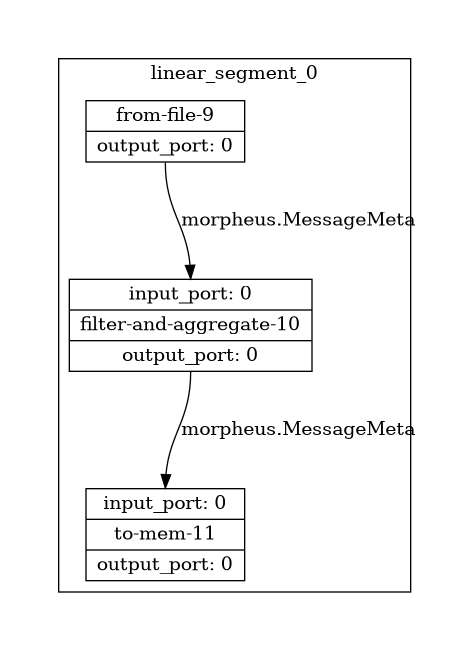

In [43]:
Image(filename=viz_file)

In [44]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250923 02:40:13.122328 140042700515136 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Building Segment: linear_segment_0====
====Pipeline Started====
Added source: <from-file-9; FileSourceStage(filename=data/pcap_dump.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <filter-and-aggregate-10; FilterAndAggregate(filter_ip=169.254.169.254, filter_port=80, filter_protocol=None)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-11; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====


--- Logging error ---
Traceback (most recent call last):
  File "/opt/conda/envs/morpheus/lib/python3.10/logging/__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
UnicodeEncodeError: 'ascii' codec can't encode characters in position 233-234: ordinal not in range(128)
Call stack:
  File "/opt/conda/envs/morpheus/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/conda/envs/morpheus/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/envs/morpheus/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
Message: 'Added source: <from-file-9; FileSourceStage(filename=data/pcap_dump.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None

====Pipeline Complete====


In [45]:
await pipeline.run_async()

In [46]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,src_ip,dest_ip,protocol,total_bytes,packet_count
0,169.254.169.254,10.100.8.98,6,17983307,147449
1,10.100.8.98,169.254.169.254,6,13113323,147582


---

## Solution

In our solution, we create an `on_data` method in our custom class definition that replicates the logic provided in the `calculate_avg_request_time` function definition above.

In [ ]:
@register_stage("filter-and-aggregate")
class FilterAndAggregate(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 filter_ip: str = None,
                 filter_port: str = None,
                 filter_protocol: str = None
                ):
        super().__init__(config)
        
        self._filter_ip = filter_ip
        self._filter_port = filter_port
        self._filter_protocol = filter_protocol

    @property
    def name(self) -> str:
        return "filter-and-aggregate"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        df = message.copy_dataframe()
        results = filter_and_aggregate_network_traffic(
            df,
            filter_ip=self._filter_ip,
            filter_port=self._filter_port,
            filter_protocol=self._filter_protocol
        )
        
        return MessageMeta(results)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

In [ ]:
config = Config()

In [ ]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
# We could instantiate our stage in any number of ways, here we follow the example above
# for _Investigating Potential AWS Metadata Service Access_.
pipeline.add_stage(FilterAndAggregate(config, filter_ip="169.254.169.254", filter_port="80"))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [ ]:
pipeline.build()

In [ ]:
viz_file = './pipeline_visualizations/filter_and_agg.png'
pipeline.visualize(viz_file)

In [ ]:
Image(filename=viz_file)

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

In [ ]:
messages = in_mem_sink.get_messages()
messages[0].get_data()